In [49]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch
import csv
from sbi.analysis import pairplot
import pandas as pd
from torch.distributions import Normal, LogNormal, Independent
from sbi.utils import MultipleIndependent

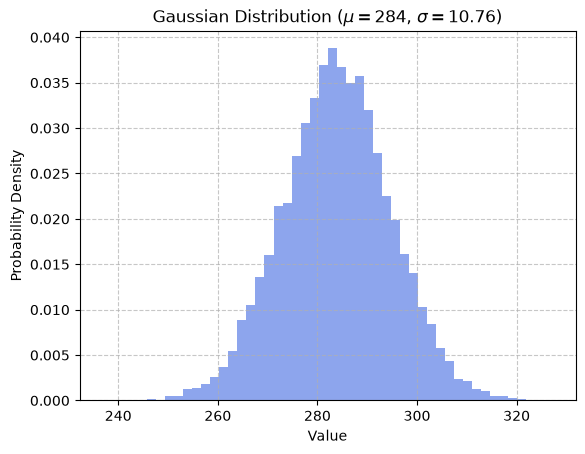

In [55]:
#set up a random gaussian
rng = np.random.default_rng(seed=42)

mu = 284  
sigma = 10.76   
N = 10000 
observed = rng.normal(loc=mu, scale=sigma, size=N)

plt.hist(observed, bins=50, density=True, alpha=0.6, color='royalblue')
plt.title(f"Gaussian Distribution ($\mu={mu}$, $\sigma={sigma}$)")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


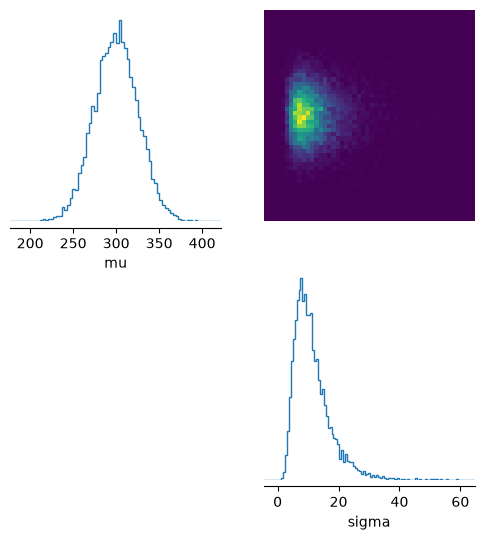

In [56]:
# and prior

prior = MultipleIndependent([
    Normal(torch.tensor([300.0], dtype=torch.float32),
           torch.tensor([25.0], dtype=torch.float32)),                 # mu
    LogNormal(torch.tensor([math.log(10.0)], dtype=torch.float32),
              torch.tensor([0.5], dtype=torch.float32)),               # sigma
])

prior_samples = prior.sample((10000,))

fig, ax = pairplot(
    prior_samples,
    labels=["mu", "sigma"],
    figsize=(6, 6)
)


In [57]:
edges = np.linspace(230, 340, 51)
centers = 0.5 * (edges[:-1] + edges[1:])
x_grid = torch.tensor(centers, dtype=torch.float32)

import math
prior = MultipleIndependent([
    Normal(torch.tensor([300.0], dtype=torch.float32),
           torch.tensor([25.0], dtype=torch.float32)),                 
    LogNormal(torch.tensor([math.log(10.0)], dtype=torch.float32),
              torch.tensor([0.5], dtype=torch.float32)),               
])

noise_std = 0.001

def simulator(theta, x=x_grid):
    mu, sigma = theta[0], theta[1]
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * torch.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return pdf + noise_std * torch.randn_like(pdf)

n_simulations = 2000
theta_train = prior.sample((n_simulations,))
x_train = torch.stack([simulator(t) for t in theta_train])

inference = NPE(prior=prior)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)


y_obs, _ = np.histogram(observed, bins=edges, density=True)
x_o = torch.tensor(y_obs, dtype=torch.float32)

post_samples = posterior.sample((5000,), x=x_o)
print(post_samples.mean(0), post_samples.std(0))  # should be near [284, 10.76]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 44, 46, 47, 48, 49] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 292 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

tensor([283.8566,  10.7819]) tensor([0.2309, 0.1853])


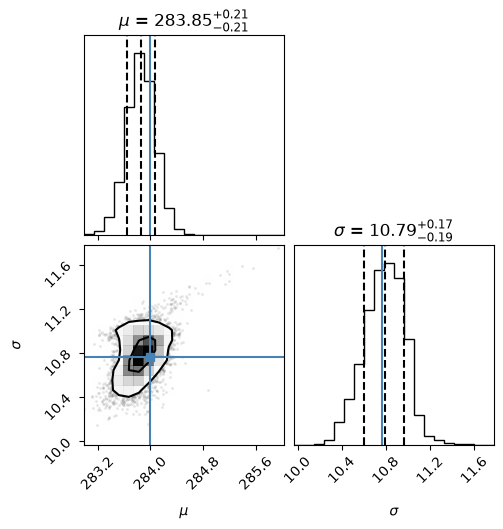

In [58]:
#Make corner plot
flat_samples = post_samples.numpy()

labels = [r"$\mu$", r"$\sigma$"]
truths = [mu, sigma]

fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})



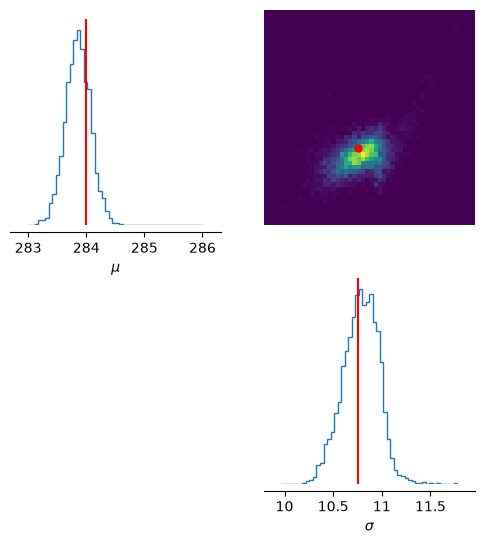

In [59]:
#plot the posterior from above
fig, axes = pairplot(
    post_samples,
    points=[[284.0, 10.76]],        
    points_colors=["red"],
    labels=[r"$\mu$", r"$\sigma$"],
    figsize=(6, 6),
)